
# 03 — Data/IA · Retrieval Error Analysis v1

## Objetivo

Analizar **uno por uno los casos críticos de Retrieval v1** (`Recall@5 = 0`) y agruparlos por **causa raíz probable**, manteniendo trazabilidad entre:

- Ground Truth oficial.
- Resultados reales enviados por Agentes.
- Chunks esperados.
- Top-5 recuperado.
- Evidencia textual.
- Clasificación de causa raíz.
- Recomendación técnica para la siguiente iteración.

> Este notebook **no modifica el retrieval**. Su función es diagnóstico y reporte desde Data/IA.

### Criterio de prioridad

- **Crítica**: `Recall@5 = 0`.
- **Alta**: `Recall@3 = 0` y `Recall@5 > 0`.
- **Media**: hay recuperación parcial cuando el Ground Truth contiene múltiples chunks relevantes.

La clasificación de causa raíz es **asistida**, no una verdad automática. El notebook propone señales y deja una tabla editable para revisión humana.


In [1]:

from pathlib import Path
import json
import re
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 220)
pd.set_option("display.max_columns", 50)

def find_data_ia_root() -> Path:
    """Busca la raíz Data_IA tanto si el notebook corre desde notebooks/ como desde otra carpeta."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in candidates:
        if (base / "data" / "evaluation").exists() and (base / "data_ai").exists():
            return base
        if (base / "Data_IA" / "data" / "evaluation").exists():
            return base / "Data_IA"
    raise FileNotFoundError(
        "No se encontró la raíz Data_IA. Ejecuta el notebook dentro del repositorio."
    )

PROJECT_ROOT = find_data_ia_root()
EVAL_DIR = PROJECT_ROOT / "data" / "evaluation"
RESULTS_DIR = EVAL_DIR / "results"
INPUT_DIR = EVAL_DIR / "input"

GROUND_TRUTH_PATH = EVAL_DIR / "ground_truth_v2.csv"
CHUNKS_PATH = EVAL_DIR / "chunks_v1.csv"
RETRIEVAL_RESULTS_PATH = RESULTS_DIR / "retrieval_results_gt_v2.csv"
AGENTS_BATCH_PATH = INPUT_DIR / "retrieval_results_agentes_v1.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Ground Truth:", GROUND_TRUTH_PATH)
print("Chunks:", CHUNKS_PATH)
print("Resultados:", RETRIEVAL_RESULTS_PATH)
print("Batch Agentes:", AGENTS_BATCH_PATH)


PROJECT_ROOT: c:\Users\MAMÁ\Downloads\NuevaMente
Ground Truth: c:\Users\MAMÁ\Downloads\NuevaMente\data\evaluation\ground_truth_v2.csv
Chunks: c:\Users\MAMÁ\Downloads\NuevaMente\data\evaluation\chunks_v1.csv
Resultados: c:\Users\MAMÁ\Downloads\NuevaMente\data\evaluation\results\retrieval_results_gt_v2.csv
Batch Agentes: c:\Users\MAMÁ\Downloads\NuevaMente\data\evaluation\input\retrieval_results_agentes_v1.json


## 1. Carga y validación de insumos

In [2]:

required_files = [
    GROUND_TRUTH_PATH,
    CHUNKS_PATH,
    RETRIEVAL_RESULTS_PATH,
    AGENTS_BATCH_PATH,
]

missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Faltan archivos requeridos:\n- " + "\n- ".join(missing)
    )

gt = pd.read_csv(GROUND_TRUTH_PATH, encoding="utf-8-sig")
chunks = pd.read_csv(CHUNKS_PATH, encoding="utf-8-sig")
results = pd.read_csv(RETRIEVAL_RESULTS_PATH)

with open(AGENTS_BATCH_PATH, "r", encoding="utf-8") as f:
    agents_batch = json.load(f)

agents_by_case = {item["case_id"]: item for item in agents_batch}

print(f"Ground Truth: {len(gt)} casos")
print(f"Chunks oficiales: {len(chunks)}")
print(f"Resultados evaluados: {len(results)} casos")
print(f"Batch de Agentes: {len(agents_batch)} casos")


Ground Truth: 50 casos
Chunks oficiales: 121
Resultados evaluados: 50 casos
Batch de Agentes: 50 casos


In [3]:

assert len(gt) == 50, f"Se esperaban 50 casos en Ground Truth y hay {len(gt)}"
assert len(results) == 50, f"Se esperaban 50 resultados y hay {len(results)}"
assert len(agents_batch) == 50, f"Se esperaban 50 payloads de Agentes y hay {len(agents_batch)}"

assert gt["case_id"].is_unique, "Ground Truth contiene case_id duplicados"
assert results["case_id"].is_unique, "Resultados contienen case_id duplicados"

missing_results = sorted(set(gt["case_id"]) - set(results["case_id"]))
extra_results = sorted(set(results["case_id"]) - set(gt["case_id"]))

print("Faltantes:", missing_results)
print("Extras:", extra_results)

assert not missing_results
assert not extra_results


Faltantes: []
Extras: []


## 2. Identificación automática de casos críticos

In [4]:

critical = (
    results.loc[results["recall_at_5"].eq(0)]
    .merge(
        gt[
            [
                "case_id",
                "document_id",
                "categoria",
                "pregunta",
                "respuesta_esperada",
                "seccion_evidencia",
                "palabras_clave_evidencia",
                "relevant_chunk_ids",
                "num_relevant_chunks",
                "notas",
            ]
        ],
        on=["case_id", "categoria", "pregunta"],
        how="left",
        suffixes=("_result", "_gt"),
    )
    .copy()
)

print(f"Casos críticos detectados: {len(critical)}")
display(
    critical[
        [
            "case_id",
            "categoria",
            "pregunta",
            "relevant_chunk_ids_gt",
            "retrieved_chunk_ids",
            "recall_at_5",
        ]
    ]
)


Casos críticos detectados: 11


,case_id,categoria,pregunta,relevant_chunk_ids_gt,retrieved_chunk_ids,recall_at_5
0,AI-ES-001-Q05,IA,¿Qué conocimiento previo puede ser útil antes de iniciar el módulo?,AI-ES-001_CH_001,"['FE-ES-002_CH_002', 'AI-ES-002_CH_002', 'DS-ES-002_CH_002', 'DS-ES-002_CH_001', 'DS-ES-001_CH_002']",0.0
1,BE-ES-001-Q02,Backend,¿Qué representa la variable app en el ejemplo inicial?,BE-ES-001_CH_011,"['BE-ES-002_CH_014', 'FE-ES-002_CH_005', 'BE-ES-001_CH_005', 'BE-ES-001_CH_019', 'FE-ES-002_CH_004']",0.0
2,BE-ES-002-Q04,Backend,¿Qué archivo contiene los ajustes o configuración del proyecto Django?,BE-ES-002_CH_008,"['BE-ES-002_CH_004', 'BE-ES-002_CH_002', 'BE-ES-002_CH_014', 'BE-ES-002_CH_003', 'BE-ES-002_CH_012']",0.0
3,DS-ES-001-Q04,Data Science,¿Qué ejercicio práctico aparece en el módulo?,DS-ES-001_CH_001,"['DS-ES-002_CH_002', 'DS-ES-001_CH_002', 'DS-ES-002_CH_001', 'FE-ES-002_CH_004', 'FE-ES-002_CH_002']",0.0
4,DS-ES-002-Q05,Data Science,¿Qué requisito previo se indica?,DS-ES-002_CH_001,"['FE-ES-002_CH_002', 'DS-ES-001_CH_002', 'CLD-ES-002_CH_003', 'DS-ES-002_CH_002', 'AI-ES-002_CH_002']",0.0
5,FE-ES-001-Q03,Frontend,¿Qué aprende el lector sobre los elementos HTML?,FE-ES-001_CH_001,"['FE-ES-001_CH_028', 'FE-ES-001_CH_049', 'FE-ES-001_CH_048', 'FE-ES-001_CH_002', 'FE-ES-001_CH_029']",0.0
6,FE-ES-001-Q05,Frontend,¿Qué puede hacer una etiqueta HTML con el contenido?,FE-ES-001_CH_002,"['FE-ES-001_CH_028', 'FE-ES-001_CH_013', 'FE-ES-001_CH_032', 'FE-ES-001_CH_005', 'FE-ES-001_CH_029']",0.0
7,FE-ES-002-Q03,Frontend,¿Para qué sirven los bucles en JavaScript?,FE-ES-002_CH_003,"['FE-ES-002_CH_007', 'FE-ES-001_CH_047', 'FE-ES-001_CH_043', 'FE-ES-002_CH_004', 'FE-ES-001_CH_022']",0.0
8,FE-ES-002-Q05,Frontend,¿El módulo se limita únicamente a sintaxis básica?,FE-ES-002_CH_001,"['DS-ES-001_CH_002', 'DS-ES-002_CH_002', 'FE-ES-002_CH_004', 'DS-ES-002_CH_001', 'AI-ES-001_CH_002']",0.0
9,CLD-ES-002-Q02,Cloud / DevOps,¿Qué conocimientos previos se piden?,CLD-ES-002_CH_003,"['FE-ES-002_CH_002', 'AI-ES-002_CH_002', 'DS-ES-002_CH_001', 'FE-ES-002_CH_007', 'AI-ES-001_CH_001']",0.0



### Resultado esperado en esta iteración

Después de la corrección del Ground Truth, deberían detectarse **11 casos críticos**.  
Si el número cambia, el notebook seguirá funcionando: significa que cambió el Ground Truth o el retrieval y debe documentarse.


In [5]:

EXPECTED_CRITICAL_V1 = {
    "AI-ES-001-Q05",
    "BE-ES-001-Q02",
    "BE-ES-002-Q04",
    "DS-ES-001-Q04",
    "DS-ES-002-Q05",
    "FE-ES-001-Q03",
    "FE-ES-001-Q05",
    "FE-ES-002-Q03",
    "FE-ES-002-Q05",
    "CLD-ES-002-Q02",
    "CLD-ES-002-Q03",
}

detected = set(critical["case_id"])
print("Coinciden con la lista esperada:", detected == EXPECTED_CRITICAL_V1)

if detected != EXPECTED_CRITICAL_V1:
    print("Solo detectados:", sorted(detected - EXPECTED_CRITICAL_V1))
    print("Solo esperados:", sorted(EXPECTED_CRITICAL_V1 - detected))


Coinciden con la lista esperada: True


## 3. Utilidades para inspección caso por caso

In [6]:

def split_chunk_ids(value):
    if pd.isna(value):
        return []
    return [x.strip() for x in str(value).split(";") if x.strip()]

chunk_lookup = chunks.set_index("chunk_id").to_dict("index")

def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )
    text = re.sub(r"[^a-z0-9_./@+-]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

STOPWORDS = {
    "que","de","la","el","los","las","un","una","unos","unas","y","o","en","del",
    "al","se","es","son","para","por","con","como","qué","cual","cuál","sobre",
    "este","esta","estos","estas","su","sus","lo","le","les","a"
}

def tokens(text: str):
    return {
        t for t in normalize_text(text).split()
        if len(t) > 2 and t not in STOPWORDS
    }

def lexical_overlap(query: str, text: str) -> float:
    q = tokens(query)
    if not q:
        return 0.0
    return len(q & tokens(text)) / len(q)

def inspect_case(case_id: str):
    gt_row = gt.loc[gt["case_id"].eq(case_id)].iloc[0]
    batch = agents_by_case[case_id]

    expected_ids = split_chunk_ids(gt_row["relevant_chunk_ids"])
    expected_rows = chunks[chunks["chunk_id"].isin(expected_ids)][
        ["chunk_id", "document_id", "categoria", "titulo_documento", "chunk_text"]
    ].copy()

    retrieved_rows = pd.DataFrame(batch["results"]).copy()
    if not retrieved_rows.empty:
        retrieved_rows["query_overlap"] = retrieved_rows["text"].apply(
            lambda x: lexical_overlap(gt_row["pregunta"], x)
        )
        retrieved_rows["same_document"] = retrieved_rows["document_id"].eq(gt_row["document_id"])

    print("=" * 110)
    print("CASE ID:", case_id)
    print("Categoría:", gt_row["categoria"])
    print("Documento esperado:", gt_row["document_id"])
    print("Pregunta:", gt_row["pregunta"])
    print("Respuesta esperada:", gt_row["respuesta_esperada"])
    print("Sección:", gt_row["seccion_evidencia"])
    print("Palabras clave:", gt_row["palabras_clave_evidencia"])
    print("Chunk(s) esperado(s):", expected_ids)

    print("\n--- EVIDENCIA ESPERADA ---")
    display(expected_rows)

    print("\n--- TOP 5 RECUPERADO ---")
    display(
        retrieved_rows[
            [
                "rank",
                "chunk_id",
                "document_id",
                "score",
                "query_overlap",
                "same_document",
                "text",
            ]
        ]
    )

    return {
        "ground_truth": gt_row,
        "expected": expected_rows,
        "retrieved": retrieved_rows,
    }


## 4. Señales diagnósticas automáticas

In [7]:

def diagnostic_signals(case_id: str) -> dict:
    gt_row = gt.loc[gt["case_id"].eq(case_id)].iloc[0]
    batch = agents_by_case[case_id]
    retrieved = batch["results"]

    retrieved_docs = [r["document_id"] for r in retrieved]
    same_doc_count = sum(d == gt_row["document_id"] for d in retrieved_docs)

    expected_ids = split_chunk_ids(gt_row["relevant_chunk_ids"])
    expected_text = " ".join(
        chunk_lookup[c]["chunk_text"]
        for c in expected_ids
        if c in chunk_lookup
    )

    q_tokens = tokens(gt_row["pregunta"])
    expected_overlap = lexical_overlap(gt_row["pregunta"], expected_text)

    retrieved_overlaps = [
        lexical_overlap(gt_row["pregunta"], r["text"])
        for r in retrieved
    ]

    keywords = [
        x.strip().lower()
        for x in str(gt_row["palabras_clave_evidencia"]).split(";")
        if x.strip()
    ]

    # Heurísticas de apoyo. No sustituyen revisión humana.
    if same_doc_count == 0:
        suggestion = "Falta de filtrado/contexto documental"
    elif same_doc_count >= 3 and max(retrieved_overlaps, default=0) >= expected_overlap:
        suggestion = "Competencia entre chunks / ranking semántico"
    elif any(
        re.search(r"[./@_]|\.py\b|\b[A-Z]{2,}\b", kw)
        for kw in keywords
    ):
        suggestion = "Entidad técnica exacta / señal lexical"
    elif len(q_tokens) <= 5:
        suggestion = "Consulta corta o ambigua"
    else:
        suggestion = "Revisión manual: posible ranking, chunking o embedding"

    return {
        "case_id": case_id,
        "categoria": gt_row["categoria"],
        "document_id_esperado": gt_row["document_id"],
        "same_document_top5": same_doc_count,
        "expected_query_overlap": round(expected_overlap, 4),
        "max_retrieved_query_overlap": round(max(retrieved_overlaps, default=0), 4),
        "sugerencia_automatica": suggestion,
    }

signals = pd.DataFrame(
    diagnostic_signals(case_id)
    for case_id in critical["case_id"]
)

display(signals)


,case_id,categoria,document_id_esperado,same_document_top5,expected_query_overlap,max_retrieved_query_overlap,sugerencia_automatica
0,AI-ES-001-Q05,IA,AI-ES-001,0,0.8750,0.3750,Falta de filtrado/contexto documental
1,BE-ES-001-Q02,Backend,BE-ES-001,2,0.4000,0.4000,Consulta corta o ambigua
2,BE-ES-002-Q04,Backend,BE-ES-002,5,0.5000,0.6667,Competencia entre chunks / ranking semántico
3,DS-ES-001-Q04,Data Science,DS-ES-001,1,0.5000,0.5000,Consulta corta o ambigua
4,DS-ES-002-Q05,Data Science,DS-ES-002,1,0.0000,0.0000,Consulta corta o ambigua
5,FE-ES-001-Q03,Frontend,FE-ES-001,5,0.7500,0.5000,Consulta corta o ambigua
6,FE-ES-001-Q05,Frontend,FE-ES-001,5,0.6000,1.0000,Competencia entre chunks / ranking semántico
7,FE-ES-002-Q03,Frontend,FE-ES-002,2,0.3333,0.6667,Consulta corta o ambigua
8,FE-ES-002-Q05,Frontend,FE-ES-002,1,0.2000,0.4000,Consulta corta o ambigua
9,CLD-ES-002-Q02,Cloud / DevOps,CLD-ES-002,0,0.6667,0.3333,Falta de filtrado/contexto documental



## 5. Revisión uno por uno

Ejecuta la siguiente celda cambiando `CASE_ID`.  
La salida muestra juntos el Ground Truth y los cinco resultados reales de Agentes.

Conviene revisar los 11 casos en este orden:

1. IA
2. Backend
3. Data Science
4. Frontend
5. Cloud / DevOps


In [8]:

CASE_ID = "AI-ES-001-Q05"

case_view = inspect_case(CASE_ID)


CASE ID: AI-ES-001-Q05
Categoría: IA
Documento esperado: AI-ES-001
Pregunta: ¿Qué conocimiento previo puede ser útil antes de iniciar el módulo?
Respuesta esperada: Un conocimiento conceptual del aprendizaje automático puede ser útil, aunque no es obligatorio.
Sección: Requisitos previos
Palabras clave: aprendizaje automático; conocimiento conceptual; útil; no obligatorio
Chunk(s) esperado(s): ['AI-ES-001_CH_001']

--- EVIDENCIA ESPERADA ---


,chunk_id,document_id,categoria,titulo_documento,chunk_text
0,AI-ES-001_CH_001,AI-ES-001,IA,Introducción a los conceptos de inteligencia artificial,# Introducción a los conceptos de inteligencia artificial\n\n- Módulo\n\n- 10 Unidades\n\n¿Tiene curiosidad por la inteligencia artificial? ¿Quieres entender de qué trata el revuelo? En este módulo se presenta el mun...



--- TOP 5 RECUPERADO ---


,rank,chunk_id,document_id,score,query_overlap,same_document,text
0,1,FE-ES-002_CH_002,FE-ES-002,0.6817,0.250,False,"Empieza aquí\n\n## Pre-requisitos\n\nAntes de empezar este módulo, deberías ya tener alguna familiaridad con lo básico de HTML y CSS , y también deberías haber trabajado todos lo módulos previos, JavaScript primeros ..."
1,2,AI-ES-002_CH_002,AI-ES-002,0.6010,0.375,False,"- Describir los conceptos básicos de los agentes y las soluciones de inteligencia artificial agente.\n\n## Requisitos previos\n\nAntes de iniciar este módulo, debería tener lo siguiente:\n\n- Familiaridad con los con..."
2,3,DS-ES-002_CH_002,DS-ES-002,0.5994,0.125,False,- Introducción min\n\n- Agregar datos min\n\n- Agrupar datos min\n\n- Visualización de datos min\n\n- Ejercicio: Análisis de datos min\n\n- Evaluación de módulos min\n\n- Resumen min\n\nResultados de la evaluación de...
3,4,DS-ES-002_CH_001,DS-ES-002,0.5620,0.250,False,"# Introducción al análisis de datos\n\n- Módulo\n\n- 7 Unidades\n\nLa conversión de datos sin procesar en información útil es esencial para los usuarios profesionales. En este módulo, se tratan los conceptos fundamen..."
4,5,DS-ES-001_CH_002,DS-ES-001,0.5503,0.125,False,- Valoración del módulo min\n\n- Resumen min\n\nResultados de la evaluación del módulo\n\nEvalúe su comprensión de este módulo. Inicie sesión y responda correctamente a todas las preguntas para obtener la designación...



## 6. Matriz de revisión humana

Las causas sugeridas se pueden editar después de inspeccionar cada caso.

Taxonomía inicial recomendada:

- `AMBIGUEDAD_CONTEXTO`: consulta demasiado genérica sin contexto del documento.
- `RANKING_SEMANTICO`: el documento correcto aparece, pero otro chunk desplaza la evidencia.
- `ENTIDAD_LEXICAL`: nombres de archivos, comandos, código o tokens exactos no son favorecidos.
- `COMPETENCIA_INTRADOCUMENTO`: varios chunks muy similares del mismo documento compiten.
- `PREGUNTA_INFERENCIAL`: la consulta requiere inferencia o negación y tiene poca correspondencia directa.
- `CHUNKING`: la evidencia quedó fragmentada o mal delimitada.
- `EMBEDDING`: la representación semántica parece no capturar adecuadamente la relación.
- `GROUND_TRUTH`: se detecta otro posible problema del etiquetado (requiere revisión antes de cambiar GT).
- `OTRO`: causa no cubierta.


In [9]:

# Clasificación inicial basada en la revisión v1.
# Puedes modificar cualquier valor después de revisar con inspect_case().

manual_review = {
    "AI-ES-001-Q05": {
        "causa_raiz": "AMBIGUEDAD_CONTEXTO",
        "evidencia": "La pregunta sobre conocimiento previo es genérica y compite con prerequisitos de otros documentos.",
        "recomendacion": "Añadir contexto de documento/categoría o aplicar prefiltrado antes del ranking.",
    },
    "BE-ES-001-Q02": {
        "causa_raiz": "RANKING_SEMANTICO",
        "evidencia": "La expresión 'variable app' tiene poca señal discriminante; el chunk exacto no entra en Top 5.",
        "recomendacion": "Probar retrieval híbrido y mayor peso a tokens técnicos/código.",
    },
    "BE-ES-002-Q04": {
        "causa_raiz": "ENTIDAD_LEXICAL",
        "evidencia": "La respuesta depende del token exacto settings.py.",
        "recomendacion": "Combinar similitud vectorial con búsqueda lexical/BM25 para nombres de archivo y comandos.",
    },
    "DS-ES-001-Q04": {
        "causa_raiz": "AMBIGUEDAD_CONTEXTO",
        "evidencia": "La pregunta 'qué ejercicio práctico' es muy genérica sin identificar el módulo.",
        "recomendacion": "Agregar contexto documental o prefiltrar por document_id.",
    },
    "DS-ES-002-Q05": {
        "causa_raiz": "AMBIGUEDAD_CONTEXTO",
        "evidencia": "La consulta sobre requisito previo compite con prerequisitos de otras categorías.",
        "recomendacion": "Prefiltrar por documento/categoría o contextualizar la consulta.",
    },
    "FE-ES-001-Q03": {
        "causa_raiz": "COMPETENCIA_INTRADOCUMENTO",
        "evidencia": "Numerosos chunks del mismo documento hablan de elementos HTML y desplazan el chunk introductorio.",
        "recomendacion": "Aplicar reranking y conservar título/sección dentro de la representación del chunk.",
    },
    "FE-ES-001-Q05": {
        "causa_raiz": "RANKING_SEMANTICO",
        "evidencia": "Muchos chunks HTML contienen términos cercanos a etiquetas/elementos y compiten con la evidencia exacta.",
        "recomendacion": "Probar híbrido BM25 + vectorial y reranking.",
    },
    "FE-ES-002-Q03": {
        "causa_raiz": "RANKING_SEMANTICO",
        "evidencia": "Se recupera contenido de JavaScript relacionado, pero no el chunk que explica explícitamente que los bucles repiten tareas.",
        "recomendacion": "Favorecer coincidencias lexicales 'bucles' + 'repetir' mediante híbrido o reranker.",
    },
    "FE-ES-002-Q05": {
        "causa_raiz": "PREGUNTA_INFERENCIAL",
        "evidencia": "La pregunta negativa requiere inferir que el módulo cubre más que sintaxis básica.",
        "recomendacion": "Revisar query de evaluación y probar reranking con contexto del título del módulo.",
    },
    "CLD-ES-002-Q02": {
        "causa_raiz": "AMBIGUEDAD_CONTEXTO",
        "evidencia": "La pregunta 'qué conocimientos previos' es transversal y recupera prerequisitos de otros dominios.",
        "recomendacion": "Añadir contexto de la ruta Cloud o prefiltrar por document_id/categoría.",
    },
    "CLD-ES-002-Q03": {
        "causa_raiz": "COMPETENCIA_INTRADOCUMENTO",
        "evidencia": "Aparecen otros chunks del mismo documento, pero no el que contiene la descripción exacta del módulo.",
        "recomendacion": "Reranking con títulos/secciones y revisar los límites de chunking en bloques de módulos.",
    },
}

review_df = pd.DataFrame(
    [
        {"case_id": case_id, **data}
        for case_id, data in manual_review.items()
    ]
).merge(
    gt[["case_id", "categoria", "pregunta"]],
    on="case_id",
    how="left",
)

review_df = review_df[
    [
        "case_id",
        "categoria",
        "pregunta",
        "causa_raiz",
        "evidencia",
        "recomendacion",
    ]
].sort_values(["categoria", "case_id"])

display(review_df)


,case_id,categoria,pregunta,causa_raiz,evidencia,recomendacion
1,BE-ES-001-Q02,Backend,¿Qué representa la variable app en el ejemplo inicial?,RANKING_SEMANTICO,La expresión 'variable app' tiene poca señal discriminante; el chunk exacto no entra en Top 5.,Probar retrieval híbrido y mayor peso a tokens técnicos/código.
2,BE-ES-002-Q04,Backend,¿Qué archivo contiene los ajustes o configuración del proyecto Django?,ENTIDAD_LEXICAL,La respuesta depende del token exacto settings.py.,Combinar similitud vectorial con búsqueda lexical/BM25 para nombres de archivo y comandos.
9,CLD-ES-002-Q02,Cloud / DevOps,¿Qué conocimientos previos se piden?,AMBIGUEDAD_CONTEXTO,La pregunta 'qué conocimientos previos' es transversal y recupera prerequisitos de otros dominios.,Añadir contexto de la ruta Cloud o prefiltrar por document_id/categoría.
10,CLD-ES-002-Q03,Cloud / DevOps,¿Qué temas cubre el módulo 'Descripción de la informática en la nube'?,COMPETENCIA_INTRADOCUMENTO,"Aparecen otros chunks del mismo documento, pero no el que contiene la descripción exacta del módulo.",Reranking con títulos/secciones y revisar los límites de chunking en bloques de módulos.
3,DS-ES-001-Q04,Data Science,¿Qué ejercicio práctico aparece en el módulo?,AMBIGUEDAD_CONTEXTO,La pregunta 'qué ejercicio práctico' es muy genérica sin identificar el módulo.,Agregar contexto documental o prefiltrar por document_id.
4,DS-ES-002-Q05,Data Science,¿Qué requisito previo se indica?,AMBIGUEDAD_CONTEXTO,La consulta sobre requisito previo compite con prerequisitos de otras categorías.,Prefiltrar por documento/categoría o contextualizar la consulta.
5,FE-ES-001-Q03,Frontend,¿Qué aprende el lector sobre los elementos HTML?,COMPETENCIA_INTRADOCUMENTO,Numerosos chunks del mismo documento hablan de elementos HTML y desplazan el chunk introductorio.,Aplicar reranking y conservar título/sección dentro de la representación del chunk.
6,FE-ES-001-Q05,Frontend,¿Qué puede hacer una etiqueta HTML con el contenido?,RANKING_SEMANTICO,Muchos chunks HTML contienen términos cercanos a etiquetas/elementos y compiten con la evidencia exacta.,Probar híbrido BM25 + vectorial y reranking.
7,FE-ES-002-Q03,Frontend,¿Para qué sirven los bucles en JavaScript?,RANKING_SEMANTICO,"Se recupera contenido de JavaScript relacionado, pero no el chunk que explica explícitamente que los bucles repiten tareas.",Favorecer coincidencias lexicales 'bucles' + 'repetir' mediante híbrido o reranker.
8,FE-ES-002-Q05,Frontend,¿El módulo se limita únicamente a sintaxis básica?,PREGUNTA_INFERENCIAL,La pregunta negativa requiere inferir que el módulo cubre más que sintaxis básica.,Revisar query de evaluación y probar reranking con contexto del título del módulo.


## 7. Agrupación por causa raíz

In [10]:

root_cause_summary = (
    review_df.groupby("causa_raiz", as_index=False)
    .agg(
        num_casos=("case_id", "count"),
        casos=("case_id", lambda s: ";".join(s)),
        categorias=("categoria", lambda s: ";".join(sorted(set(s)))),
    )
    .sort_values(["num_casos", "causa_raiz"], ascending=[False, True])
)

display(root_cause_summary)


,causa_raiz,num_casos,casos,categorias
0,AMBIGUEDAD_CONTEXTO,4,CLD-ES-002-Q02;DS-ES-001-Q04;DS-ES-002-Q05;AI-ES-001-Q05,Cloud / DevOps;Data Science;IA
4,RANKING_SEMANTICO,3,BE-ES-001-Q02;FE-ES-001-Q05;FE-ES-002-Q03,Backend;Frontend
1,COMPETENCIA_INTRADOCUMENTO,2,CLD-ES-002-Q03;FE-ES-001-Q03,Cloud / DevOps;Frontend
2,ENTIDAD_LEXICAL,1,BE-ES-002-Q04,Backend
3,PREGUNTA_INFERENCIAL,1,FE-ES-002-Q05,Frontend


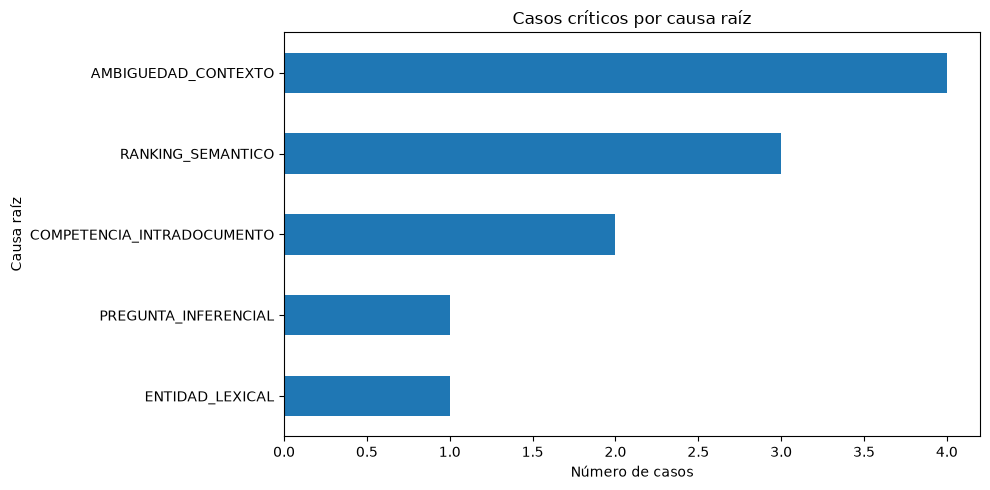

In [11]:

plt.figure(figsize=(10, 5))
counts = review_df["causa_raiz"].value_counts().sort_values()
counts.plot(kind="barh")
plt.title("Casos críticos por causa raíz")
plt.xlabel("Número de casos")
plt.ylabel("Causa raíz")
plt.tight_layout()
plt.show()


## 8. Reporte por categoría

In [12]:

category_root_cause = pd.crosstab(
    review_df["categoria"],
    review_df["causa_raiz"],
)

display(category_root_cause)


causa_raiz,AMBIGUEDAD_CONTEXTO,COMPETENCIA_INTRADOCUMENTO,ENTIDAD_LEXICAL,PREGUNTA_INFERENCIAL,RANKING_SEMANTICO
categoria,,,,,
Backend,0,0,1,0,1
Cloud / DevOps,1,1,0,0,0
Data Science,2,0,0,0,0
Frontend,0,1,0,1,2
IA,1,0,0,0,0


## 9. Exportación de resultados

In [13]:

ERROR_ANALYSIS_PATH = RESULTS_DIR / "retrieval_error_analysis_gt_v2.csv"
ROOT_CAUSE_SUMMARY_PATH = RESULTS_DIR / "retrieval_root_cause_summary_gt_v2.csv"
CATEGORY_ROOT_CAUSE_PATH = RESULTS_DIR / "retrieval_root_cause_by_category_gt_v2.csv"

review_export = review_df.merge(
    results[
        [
            "case_id",
            "relevant_chunk_ids",
            "retrieved_chunk_ids",
            "recall_at_3",
            "recall_at_5",
            "precision_at_3",
            "precision_at_5",
        ]
    ],
    on="case_id",
    how="left",
)

review_export.to_csv(ERROR_ANALYSIS_PATH, index=False, encoding="utf-8-sig")
root_cause_summary.to_csv(ROOT_CAUSE_SUMMARY_PATH, index=False, encoding="utf-8-sig")
category_root_cause.to_csv(CATEGORY_ROOT_CAUSE_PATH, encoding="utf-8-sig")

print("Generados:")
print("-", ERROR_ANALYSIS_PATH)
print("-", ROOT_CAUSE_SUMMARY_PATH)
print("-", CATEGORY_ROOT_CAUSE_PATH)


Generados:
- c:\Users\MAMÁ\Downloads\NuevaMente\data\evaluation\results\retrieval_error_analysis_gt_v2.csv
- c:\Users\MAMÁ\Downloads\NuevaMente\data\evaluation\results\retrieval_root_cause_summary_gt_v2.csv
- c:\Users\MAMÁ\Downloads\NuevaMente\data\evaluation\results\retrieval_root_cause_by_category_gt_v2.csv



## 10. Interpretación para compartir con Agentes

El propósito del reporte no es indicar únicamente que un caso “falló”, sino diferenciar **qué tipo de intervención podría mejorar el retrieval**.

Interpretación sugerida:

- Muchos casos `AMBIGUEDAD_CONTEXTO` → considerar filtros por metadata (`document_id`, categoría) o query contextualization.
- Muchos `RANKING_SEMANTICO` → evaluar reranker o una segunda etapa de ranking.
- Casos `ENTIDAD_LEXICAL` → probar retrieval híbrido vectorial + BM25.
- `COMPETENCIA_INTRADOCUMENTO` → revisar chunking, títulos/secciones y reranking.
- `PREGUNTA_INFERENCIAL` → revisar tanto la formulación de las preguntas como la capacidad del retrieval para consultas indirectas.

### Siguiente experimento recomendado

Mantener **exactamente los mismos 50 casos del Ground Truth** y solicitar a Agentes una versión v2.  
Después comparar v1 vs. v2 con el mismo pipeline para medir si los cambios producen una mejora real y reproducible.
